Note: Use this template to develop your project. Do not change the steps. For each step, you may add additional cells if needed.

#### Group Information

Group No: Seismic2

- Member 1: AHMAD ADAM BIN MOHD RUJHAN (22303490)
- Member 2: WAN MUHAMMAD ADAM BIN WAN MOHD FAUZI (22304170)
- Member 3: AIRIEL HAZIM BIN REDZUAN NG (22304117)
- Member 4: MUHAMMAD DANNI MIQHAIL BIN SHAMSUL FAZILY (22303734)

#### Import Libraries

In [13]:
# Disable Jedi for better autocompletion in Jupyter
%config Completer.use_jedi=False

!pip install tensorflow

# Import required libraries
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

#### Load the dataset

In [14]:
# Load dataset from CSV file
dataset = pd.read_csv('classification_dataset.csv')

#### Define the loss function

In [15]:
def loss_fn(y, yhat):
    """
    This function calculates the loss function
    
    Calculate binary cross-entropy loss.

    Parameters:
    y (tensor): Actual label
    yhat (tensor): Predicted value (probability)

    Returns:
    Tensor: Loss value
    """
    epsilon = 1e-7  # A small value to avoid log(0)
    yhat = tf.clip_by_value(yhat, epsilon, 1.0 - epsilon)
    loss = -tf.reduce_mean(y * tf.math.log(yhat) + (1 - y) * tf.math.log(1 - yhat))
    return loss

#### Define function to perform prediction

In [16]:
def sigmoid(z):
    """ 
    This function calculates the sigmoid function.
    """
    return 1 / (1 + tf.exp(-z))
    
def relu(z):
    """ 
    This function calculates the ReLU function.
    """
    return tf.maximum(0.0, z)
    
def forward(W, B, x):
    """ 
    This function calculates the forward pass (predicts the label).

    Perform the forward pass of the neural network.

    Parameters:
    W (list): List of weight tensors
    B (list): List of bias tensors
    x (tensor): Input features

    Returns:
    Tensor: Output predictions
    """
    # Hidden layer with ReLU activation
    z1 = tf.add(tf.matmul(x, W[0]), B[0])
    a1 = relu(z1)
    
    # Output layer with sigmoid activation
    z2 = tf.add(tf.matmul(a1, W[1]), B[1])
    a2 = sigmoid(z2)
    
    return a2

#### Define function for model training
Display the training and validation loss values for each epoch of the training loop. The displayed value must be in 6 decimal places.<br>
Hint: <br>
Use `tf.GradientTape` to compute the gradients.

In [17]:
def train(W, B, x, y, alpha):
    """ 
    This function performs the forward pass, computes the gradient and update the weights and biases.
    
    Perform one training step (forward + backward pass).

    Parameters:
    W (list): Weights
    B (list): Biases
    x (tensor): Batch input
    y (tensor): Batch label
    alpha (float): Learning rate

    Returns:
    Tensor: Training loss
    """
    with tf.GradientTape() as tape:
        yhat = forward(W, B, x)
        loss = loss_fn(y, yhat)
    
    # Compute gradients with respect to weights and biases
    trainable_variables = [*W, *B]
    gradients = tape.gradient(loss, trainable_variables)
    
    # Update weights and biases using gradient descent
    for i in range(len(trainable_variables)):
        trainable_variables[i].assign_sub(alpha * gradients[i])
    
    return loss

def fit(model, train_ds, vald_ds, batch_size, alpha, max_epochs, patience=5):
    """ 
    This function implements the training loop with early stopping based on patience.

    Train the model using mini-batch gradient descent.

    Parameters:
    model (list): [W, B]
    train_ds (tuple): Training dataset (X, y)
    vald_ds (tuple): Validation dataset (X, y)
    batch_size (int): Mini-batch size
    alpha (float): Learning rate
    max_epochs (int): Number of training epochs
    patience (int): Number of epochs to wait for improvement before stopping

    Returns:
    Tuple: Lists of training and validation losses
    """
    W, B = model
    train_losses = []
    vald_losses = []

    best_val_loss = float('inf')
    patience_counter = 5
    
    for epoch in range(max_epochs):
        epoch_loss = []
        
        # Training step (mini-batch)
        for i in range(0, len(train_ds[0]), batch_size):
            x_batch = train_ds[0][i:i+batch_size]
            y_batch = train_ds[1][i:i+batch_size]
            
            loss = train(W, B, x_batch, y_batch, alpha)
            epoch_loss.append(loss.numpy())
        
        # Calculate average training loss for the epoch
        avg_train_loss = np.mean(epoch_loss)
        train_losses.append(avg_train_loss)
        
        # Validation step
        vald_loss = []
        for i in range(0, len(vald_ds[0]), batch_size):
            x_batch = vald_ds[0][i:i+batch_size]
            y_batch = vald_ds[1][i:i+batch_size]
            
            yhat = forward(W, B, x_batch)
            loss = loss_fn(y_batch, yhat)
            vald_loss.append(loss.numpy())
        
        # Calculate average validation loss for the epoch
        avg_vald_loss = np.mean(vald_loss)
        vald_losses.append(avg_vald_loss)
        
        # Display loss values with 6 decimal places
        print(f"Epoch {epoch+1}/{max_epochs} - "
              f"Train Loss: {avg_train_loss:.6f} - "
              f"Validation Loss: {avg_vald_loss:.6f}")
        
        # Early stopping with patience
        if avg_vald_loss < best_val_loss:
            best_val_loss = avg_vald_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    return train_losses, vald_losses


#### Define the tensors to hold the weights and biases (create the model)
Hint: <br>
Use `tf.Variable` to create the tensors.<br>
Put the tensors in a list.

In [18]:
# Define number of hidden units
hidden_units = 30

# Set a fixed random seed for reproducibility
tf.random.set_seed(0)

# Weights and biases initialization with float32
W = [
    tf.Variable(tf.random.normal([5, hidden_units], dtype=tf.float32)),  # Input -> Hidden
    tf.Variable(tf.random.normal([hidden_units, 1], dtype=tf.float32))   # Hidden -> Output
]

B = [
    tf.Variable(tf.zeros([hidden_units], dtype=tf.float32)),             # Hidden bias
    tf.Variable(tf.zeros([1], dtype=tf.float32))                         # Output bias
]

model = [W, B]

#### Split the dataset
The ratio of training and test is 7:1:2.

In [19]:
# Separate features and labels
x = dataset[['f1', 'f2', 'f3', 'f4', 'f5']].values.astype(np.float32)
y = dataset['label'].values.astype(np.float32).reshape(-1, 1)

# Split data into train (70%), val (10%), test (20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1, stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.125, random_state=1, stratify=y_train) 

#### Normalize the data

In [20]:
# Initialize the MinMaxScale
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
x_train = scaler.fit_transform(x_train)

# Use the same scaler to transform the validation and test sets
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

#### Train the model

In [21]:
# Prepare dataset tuples
train_ds = (x_train, y_train)
vald_ds = (x_val, y_val)

# Training parameters
batch_size = 200
alpha = 0.1
max_epochs = 500

# Run training loop
train_losses, vald_losses = fit(model, train_ds, vald_ds, batch_size, alpha, max_epochs)

Epoch 1/500 - Train Loss: 1.031583 - Validation Loss: 0.802856
Epoch 2/500 - Train Loss: 0.708047 - Validation Loss: 0.566225
Epoch 3/500 - Train Loss: 0.508333 - Validation Loss: 0.419413
Epoch 4/500 - Train Loss: 0.402558 - Validation Loss: 0.350649
Epoch 5/500 - Train Loss: 0.348375 - Validation Loss: 0.313300
Epoch 6/500 - Train Loss: 0.315611 - Validation Loss: 0.288670
Epoch 7/500 - Train Loss: 0.292504 - Validation Loss: 0.270146
Epoch 8/500 - Train Loss: 0.274173 - Validation Loss: 0.254999
Epoch 9/500 - Train Loss: 0.259066 - Validation Loss: 0.242775
Epoch 10/500 - Train Loss: 0.246288 - Validation Loss: 0.232392
Epoch 11/500 - Train Loss: 0.235273 - Validation Loss: 0.223139
Epoch 12/500 - Train Loss: 0.225420 - Validation Loss: 0.214933
Epoch 13/500 - Train Loss: 0.216566 - Validation Loss: 0.207628
Epoch 14/500 - Train Loss: 0.208628 - Validation Loss: 0.201132
Epoch 15/500 - Train Loss: 0.201574 - Validation Loss: 0.195363
Epoch 16/500 - Train Loss: 0.195194 - Validation 

#### Display the training loss and validation loss against epoch graph

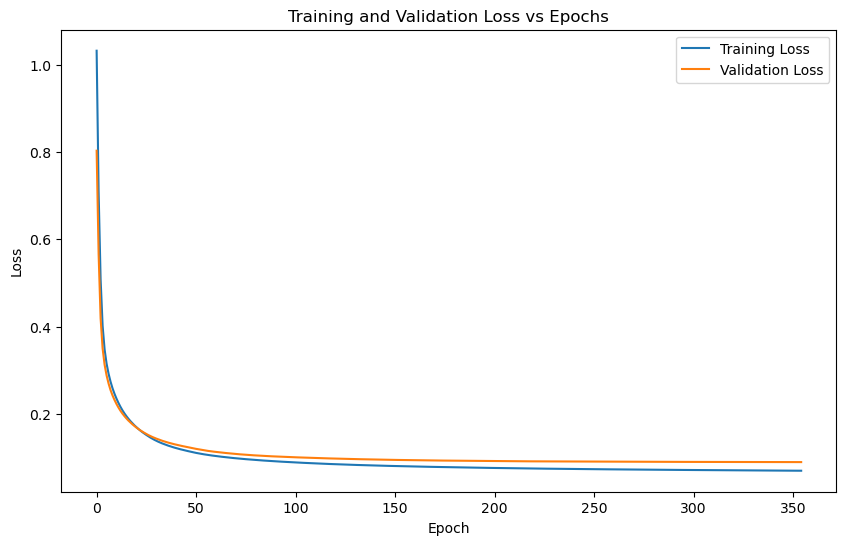

In [22]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(vald_losses, label='Validation Loss')
plt.title('Training and Validation Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### Predict the test set

In [23]:
# Predict and round output to nearest class (0 or 1)
y_pred = forward(W, B, x_test)
y_pred = tf.round(y_pred).numpy()

#### Display the confusion matrix and the classification report.

In [24]:
# Print confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[100   0]
 [  0 100]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       100
         1.0       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

